# Block 5 — SOLUTION: Linear Models — SVM & k-Fold Cross-Validation
### Advanced Machine Learning — M&T Bank

Loads `bank_marketing_features.csv` (unchanged since Block 3). Same feature prep as Block 4: drop the raw
`education` string column and `duration` (our confirmed leakage feature), scale the continuous numeric columns.
No new CSV comes out of this lab either.

**Part 1 — SVM, visualized:** compress our feature set to 2 dimensions with PCA (purely so we can *see* a decision
boundary), then fit a linear-kernel and an RBF-kernel SVM side by side.

**Part 2 — SVM at full scale:** fit `LinearSVC` on the real feature set with a single train/test split, and compare
directly to Block 4's logistic regression numbers.

**Part 3 — k-Fold Cross-Validation:** stop trusting a single split. Run 5-fold CV on both models and see how much
that one split number actually moves around.


## Setup

In [ ]:
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
LT_PINK = "#FBD6E6"
LT_NAVY = "#EBEFF5"

# Data source: https://raw.githubusercontent.com/mithun-rk/mt-advml-course/main/Data/bank_marketing_features.csv
df = pd.read_csv("https://raw.githubusercontent.com/mithun-rk/mt-advml-course/main/Data/bank_marketing_features.csv", sep=";")
print(df.shape)
df.head()


In [2]:
# Same prep pattern as Block 4: drop the leaky/redundant-string columns, cast one-hot booleans to int
feature_cols = [c for c in df.columns if c not in ("education", "y", "duration")]
bool_cols = [c for c in df[feature_cols].columns if df[c].dtype == bool]

numeric_to_scale = [
    "age", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "education_rank", "month_sin", "month_cos", "campaign_intensity",
    "emp.var.rate_denoised", "cons.price.idx_denoised", "cons.conf.idx_denoised",
    "euribor3m_denoised", "nr.employed_denoised",
]

X = df[feature_cols].copy()
for c in bool_cols:
    X[c] = X[c].astype(int)
y = df["y"].values

print(f"{len(feature_cols)} features (duration already excluded, per Block 4's leakage finding)")


47 features (duration already excluded, per Block 4's leakage finding)


# Part 1 — SVM, Visualized

### Task 1.1 — Compress to 2 dimensions so we can actually see a boundary

We can't plot a decision boundary in 47-dimensional space. Standardize the full feature set, then use PCA to
project it down to 2 components — purely as a visualization aid, the same tool from Block 3, borrowed for a new
purpose.


In [3]:
viz_sample = df.sample(1500, random_state=3).copy()
for c in bool_cols:
    viz_sample[c] = viz_sample[c].astype(int)

X_viz_scaled = StandardScaler().fit_transform(viz_sample[feature_cols])
pca_viz = PCA(n_components=2, random_state=0)
X_viz_2d = pca_viz.fit_transform(X_viz_scaled)
y_viz = viz_sample["y"].values

print("variance captured by these 2 components:", pca_viz.explained_variance_ratio_.round(3),
      "-- a small slice of the total signal, enough to look at a boundary, not to judge accuracy")


variance captured by these 2 components: [0.189 0.073] -- a small slice of the total signal, enough to look at a boundary, not to judge accuracy


### Task 1.2 — Fit a linear-kernel and an RBF-kernel SVM on the same 2D data

**Hint:** `SVC(kernel="linear", C=1.0)` and `SVC(kernel="rbf", C=1.0, gamma="scale")`.


In [4]:
svm_linear = SVC(kernel="linear", C=1.0)
svm_linear.fit(X_viz_2d, y_viz)

svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_rbf.fit(X_viz_2d, y_viz)

print("linear train accuracy:", round(svm_linear.score(X_viz_2d, y_viz), 3))
print("rbf train accuracy:   ", round(svm_rbf.score(X_viz_2d, y_viz), 3))


linear train accuracy: 0.895
rbf train accuracy:    0.904


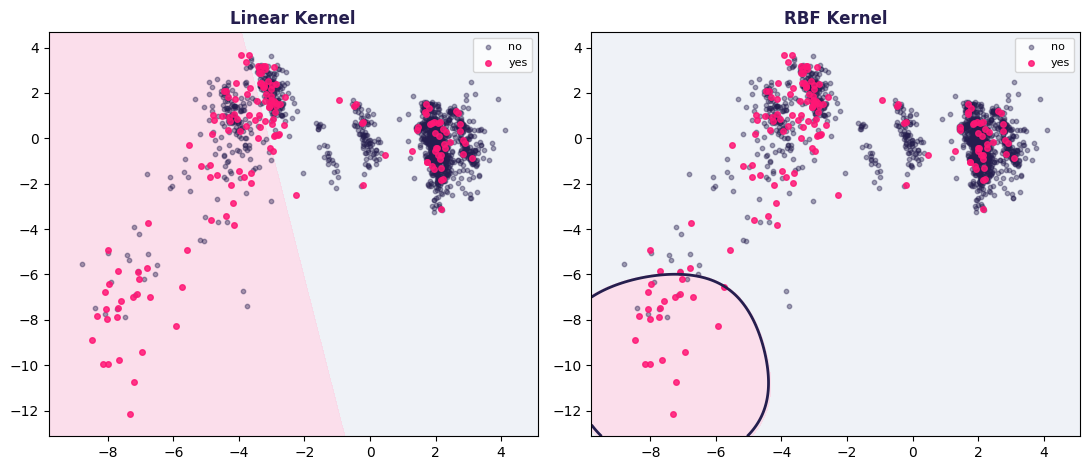

In [5]:
xx, yy = np.meshgrid(
    np.linspace(X_viz_2d[:, 0].min() - 1, X_viz_2d[:, 0].max() + 1, 300),
    np.linspace(X_viz_2d[:, 1].min() - 1, X_viz_2d[:, 1].max() + 1, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model, title in zip(axes, [svm_linear, svm_rbf], ["Linear Kernel", "RBF Kernel"]):
    Z = model.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 3), colors=[LT_NAVY, LT_PINK], alpha=0.8)
    ax.contour(xx, yy, Z, levels=[0], colors=NAVY, linewidths=2)
    ax.scatter(X_viz_2d[y_viz == 0, 0], X_viz_2d[y_viz == 0, 1], s=10, color=NAVY, alpha=0.4, label="no")
    ax.scatter(X_viz_2d[y_viz == 1, 0], X_viz_2d[y_viz == 1, 1], s=16, color=PINK, alpha=0.85, label="yes")
    ax.set_title(title, color=NAVY, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()


**Talking point:** the linear kernel can only ever draw a straight cut through the space — here, one diagonal line.
The RBF kernel drew something no straight line ever could: a closed curve wrapped tightly around the small cluster
of "yes" cases in the bottom-left, at the cost of a far more complex boundary. That's the kernel trick in one
picture — RBF implicitly projects into a much higher-dimensional space where a straight cut *there* looks curved
back here. More flexible, but also more prone to memorizing quirks of these particular 1,500 points.


# Part 2 — SVM at Full Scale

### Task 2.1 — Fit `LinearSVC` on the real feature set

A full RBF-kernel `SVC` doesn't scale to 41,188 rows — kernel SVMs are roughly quadratic-to-cubic in the number of
training points. `LinearSVC` uses a different, much faster solver built specifically for the linear-kernel case,
which is exactly what makes SVMs usable on tabular data at this size.

**Hint:** same `train_test_split` pattern as Block 4 (`test_size=0.2`, `stratify=y`, `random_state=42`), then scale
`numeric_to_scale` the same way.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test_scaled[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])

t0 = time.time()
svm_full = LinearSVC(C=0.5, max_iter=5000, dual="auto")
svm_full.fit(X_train_scaled, y_train)
svm_scores = svm_full.decision_function(X_test_scaled)
print(f"fit time: {time.time() - t0:.2f}s")

svm_auc = roc_auc_score(y_test, svm_scores)
svm_acc = accuracy_score(y_test, svm_full.predict(X_test_scaled))
print("LinearSVC  -- accuracy:", round(svm_acc, 4), " ROC-AUC:", round(svm_auc, 4))


fit time: 0.39s
LinearSVC  -- accuracy: 0.8996  ROC-AUC: 0.7912


### Task 2.2 — Compare against Block 4's logistic regression

Same split, same features, same `C`. Fit `LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5)` for a direct
comparison.


In [7]:
logit_full = LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5)
logit_full.fit(X_train_scaled, y_train)
logit_proba = logit_full.predict_proba(X_test_scaled)[:, 1]
logit_auc = roc_auc_score(y_test, logit_proba)

comparison = pd.DataFrame({
    "Model": ["LinearSVC", "LogisticRegression"],
    "Accuracy": [svm_acc, round(accuracy_score(y_test, logit_full.predict(X_test_scaled)), 4)],
    "ROC-AUC": [round(svm_auc, 4), round(logit_auc, 4)],
}).round(4)
comparison


,Model,Accuracy,ROC-AUC
0,LinearSVC,0.8996,0.7912
1,LogisticRegression,0.8996,0.7958


Close, but LinearSVC comes in a hair behind logistic regression on this dataset — with a linear kernel, both models
are drawing essentially the same kind of straight-line boundary through the same features, so it would be
surprising if they landed far apart. The real question — is either of these single numbers something you'd want
to put in a model validation document as *the* performance estimate? That's what Part 3 is about.


# Part 3 — k-Fold Cross-Validation: Stop Trusting One Split

### Task 3.1 — Build a leakage-safe pipeline

**Important:** the scaler has to be fit fresh inside *each* fold, on that fold's training data only — fitting it
once on the whole dataset before cross-validating would let each test fold's statistics quietly leak into the
scaler. A `Pipeline` handles this automatically: `cross_val_score` refits the whole pipeline, scaler included, on
each fold's training split.

**Hint:** `ColumnTransformer([("scale", StandardScaler(), numeric_to_scale)], remainder="passthrough")`, wrapped
in a `Pipeline` with the classifier.


In [8]:
preprocessor = ColumnTransformer(
    [("scale", StandardScaler(), numeric_to_scale)],
    remainder="passthrough",
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


### Task 3.2 — Run 5-fold cross-validation for both models

**Hint:** wrap each classifier in `Pipeline([("pre", preprocessor), ("clf", ...)])`, then
`cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")`.


In [9]:
cv_results = {}
for name, clf in [
    ("LogisticRegression", LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5)),
    ("LinearSVC", LinearSVC(C=0.5, max_iter=5000, dual="auto")),
]:
    pipe = Pipeline([("pre", preprocessor), ("clf", clf)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name:20s} folds: {[round(s, 4) for s in scores]}")
    print(f"{'':20s} mean = {scores.mean():.4f}   std = {scores.std():.4f}")


LogisticRegression   folds: [np.float64(0.7763), np.float64(0.7777), np.float64(0.7985), np.float64(0.778), np.float64(0.7836)]
                     mean = 0.7828   std = 0.0083


LinearSVC            folds: [np.float64(0.7739), np.float64(0.7691), np.float64(0.7962), np.float64(0.7725), np.float64(0.7812)]
                     mean = 0.7786   std = 0.0096


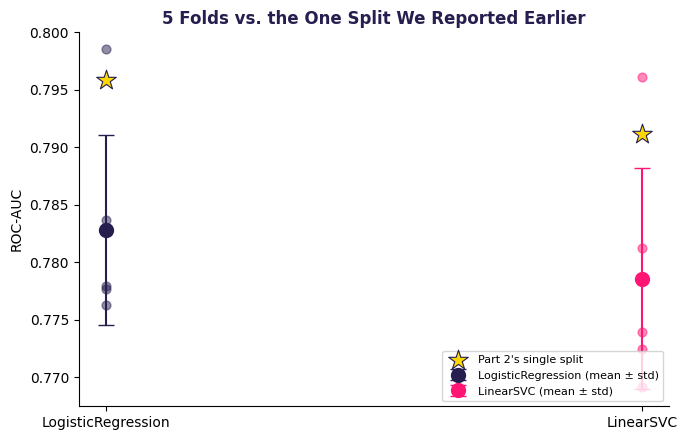

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (name, scores) in enumerate(cv_results.items()):
    color = NAVY if name == "LogisticRegression" else PINK
    ax.scatter([i] * len(scores), scores, color=color, alpha=0.5, s=40, zorder=2)
    ax.errorbar(i, scores.mean(), yerr=scores.std(), fmt="o", color=color,
                markersize=10, capsize=6, zorder=3, label=f"{name} (mean ± std)")

single_split = {"LogisticRegression": logit_auc, "LinearSVC": svm_auc}
for i, name in enumerate(cv_results.keys()):
    ax.scatter(i, single_split[name], marker="*", s=220, color="gold",
               edgecolor=NAVY, linewidth=0.8, zorder=4,
               label="Part 2's single split" if i == 0 else None)

ax.set_xticks(range(len(cv_results)))
ax.set_xticklabels(cv_results.keys())
ax.set_ylabel("ROC-AUC")
ax.set_title("5 Folds vs. the One Split We Reported Earlier", color=NAVY, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**The point of this whole exercise:** the gold star is the single train/test split number from Part 2 — the exact
same number you'd get if you ran the notebook once and reported it. Look at where it lands relative to the five
individual fold scores (the dots) and the mean-±-std bar. A single split isn't wrong, but it's one draw from a
distribution — the fold spread is what tells you how much that number would have moved if `random_state=42` had
been `43` instead. For a model that will end up in a validation document, the mean ± std *is* the honest answer;
the single-split number alone is not.


## Recap

- The kernel trick lets an SVM draw boundaries a straight line never could — flexibility that helps on genuinely
  nonlinear problems, and hurts (via overfitting, and via not scaling) on large tabular data where the extra
  flexibility usually isn't needed.
- `LinearSVC` is the practical SVM for datasets this size — a full kernel `SVC` would not have finished fitting
  41,188 rows in a live class.
- k-fold cross-validation isn't a nice-to-have — a single train/test split is one sample from a distribution of
  possible outcomes, and the fold-to-fold spread is what tells you how much to trust it.
- No new CSV from this block — `bank_marketing_features.csv` carries forward unchanged.

**Up next — Block 6:** Evaluating Models — Metrics & Hyperparameter Tuning.
